Dataset shape: (150, 4)
Number of classes: 3

Neural Network Architecture:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323 (1.26 KB)

 Trainable params: 323 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3333 - loss: 1.3091 - val_accuracy: 0.4167 - val_loss: 1.1190
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3438 - loss: 1.1427 - val_accuracy: 0.4583 - val_loss: 1.0045
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4167 - loss: 1.0130 - val_accuracy: 0.5000 - val_loss: 0.9155
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6458 - loss: 0.8989 - val_accuracy: 0.7083 - val_loss: 0.8460
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7917 - loss: 0.8126 - val_accuracy: 0.7083 - val_loss: 0.7879
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8438 - loss: 0.7406 - val_accuracy: 0.7083 - val_loss: 0.7394
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8438 - loss: 0.6822 - val_accuracy: 0.7083 - val_loss: 0.6964
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8438 - loss: 0.6333 - val_accuracy: 0.7083 - v

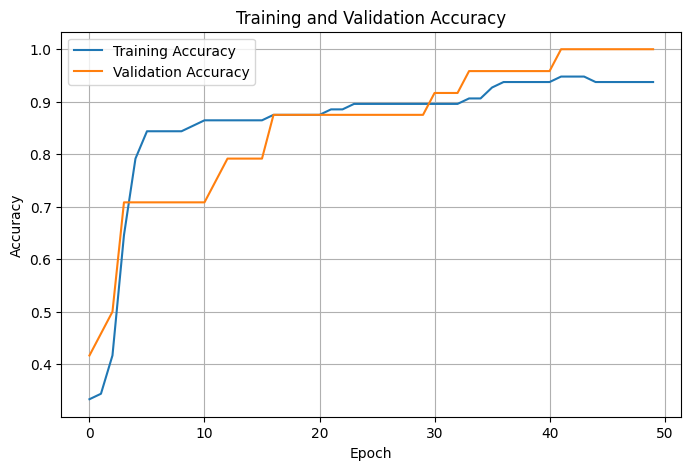

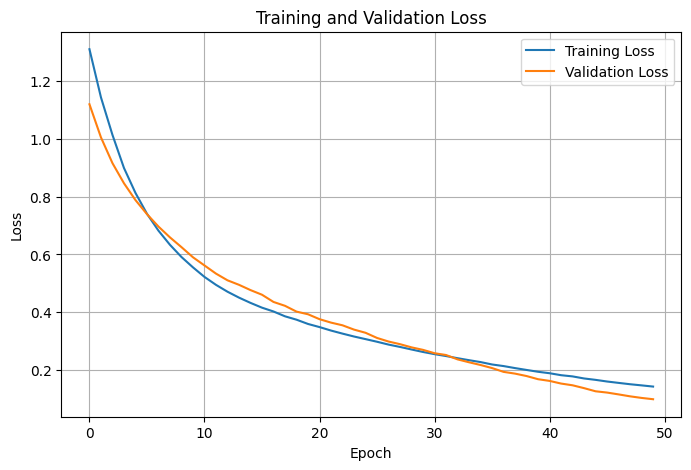

In [1]:
# Experiment 8: Feedforward Neural Network using TensorFlow/Keras

# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 4: Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Build a Feedforward Neural Network using Keras
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(12, activation='relu'),
    Dense(3, activation='softmax')
])

# Step 6: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\nNeural Network Architecture:")
model.summary()

# Step 7: Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# Step 8: Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Step 9: Display accuracy and loss
print("\nTest Results")
print("------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Original Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Standardized Dataset:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

Transformed Dataset:
   Principal Component 1  Principal Component 2
0              -2.264703               0.480027
1              -2.080961              -0.674134
2              -2.364229              -0.341908
3              -2.299384         

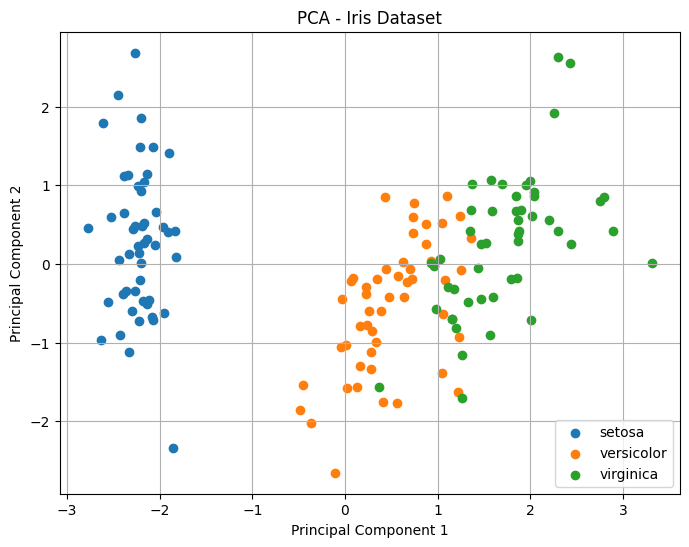

In [2]:
# Experiment 7: Dimensionality Reduction Using PCA

# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 2: Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

# Create a DataFrame for displaying the original dataset
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

print("Original Dataset:")
print(df.head())

# Step 3: Standardize the dataset
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Dataset:")
print(X_scaled[:5])

# Step 4: Apply PCA and choose the number of components
pca = PCA(n_components=2)

# Step 5: Transform the data into principal components
X_pca = pca.fit_transform(X_scaled)

# Step 6: Display the transformed dataset
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

print("\nTransformed Dataset:")
print(pca_df.head(10))

# Display explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Preserved:")
print(sum(pca.explained_variance_ratio_))

# Step 7: Visualize the reduced data using a scatter plot

plt.figure(figsize=(8, 6))

for target in range(3):
    plt.scatter(
        X_pca[y == target, 0],
        X_pca[y == target, 1],
        label=iris.target_names[target]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()